# Notebook 4 · Hybrid Quantum-Classical Models

### SDS2026 Workshop — *Quantum AI: From Inspiration to Enhancement - A Practical Journey*

This lab builds a small hybrid classifier. The quantum circuit is used as a
differentiable layer inside an otherwise standard PyTorch workflow.

Key terms:

- **QNN** (Quantum Neural Network): a parameterized quantum circuit wrapped as a differentiable model layer.
- **PQC** (Parameterized Quantum Circuit): a circuit whose gates contain trainable parameters.
- **Angle encoding**: a map from classical features to rotation angles.
- **Variational sampler**: a trainable circuit whose measurement probabilities are shaped by a classical optimiser.

| Part | Topic | Technique |
|------|-------|-----------|
| A | QNN classifier | `qml.qnn.TorchLayer` inside `nn.Sequential` |
| B | Finance example | train a circuit to favour low-cost portfolios |
| C | Logistics example | train a circuit to favour short routes |


## Reading guide

A hybrid quantum-classical model is still a normal machine-learning pipeline:
data goes in, parameters are updated, and performance is checked on held-out
data. The circuit is useful only if it gives a better modelling bias than a
classical baseline for the task at hand.

The realistic hope is not automatic accuracy. A circuit may represent some
correlation patterns compactly, change the sampling distribution in a useful
way, converge with fewer updates, or overfit less for a particular dataset.
Each of these claims has to be tested.


## Useful background

Before training the hybrid model, it helps to recognise three ingredients:

- state vectors, normalization, and Born probabilities;
- multi-qubit basis states such as $|00\rangle$, $|01\rangle$, $|10\rangle$, $|11\rangle$;
- the idea that classical features become gate parameters, not raw inputs to a quantum device.

The mini-lab below introduces the encoding patterns used later in the classifier and optimisation examples.


## Hybrid Architecture Overview

```
Input x
  │
  ▼
[Classical pre-processor]  ─── Linear + Tanh
  │
  ▼
[Quantum Layer (PQC)]      ─── Angle embedding → Entanglement → Measurement
                                Gradients via parameter-shift rule
  │
  ▼
[Classical post-processor] ─── Linear → sigmoid / softmax
  │
  ▼
Output (loss → .backward() propagates through all layers)
```

**Key:** `qml.qnn.TorchLayer` wraps a QNode as an `nn.Module`, so PyTorch's optimizer sees both classical and quantum parameters in one unified `model.parameters()` iterator.

---
## Imports & Device Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import pennylane as qml
import pennylane.numpy as pnp
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

torch.manual_seed(42)
np.random.seed(42)

print(f'PyTorch  : {torch.__version__}')
print(f'PennyLane: {qml.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')

PyTorch  : 2.10.0+cu130
PennyLane: 0.44.0
CUDA available: True


## Prerequisite mini-lab · Data encoding for hybrid circuits

A quantum circuit starts in $|0\ldots0\rangle$ by default. Classical data must
be encoded into gates or amplitudes before trainable layers can use it.

The examples below are intentionally small. Change the numbers and rerun the
cells to see how the state and measurement probabilities change.


### Angle encoding: one number

With one qubit, a scalar feature can become a rotation angle. Starting from
$|0\rangle$,
$$
R_Y(\theta)|0\rangle
=
\cos(\theta/2)|0\rangle + \sin(\theta/2)|1\rangle .
$$

For $\theta=\pi/3$, this is
$\sqrt{3}/2|0\rangle + 1/2|1\rangle$, so measurement gives probabilities
$P(0)=0.75$ and $P(1)=0.25$.


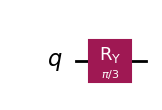

state amplitudes [|0>, |1>]: [0.866+0.j 0.5  +0.j]
measurement probabilities: [0.75 0.25]


In [2]:
from IPython.display import display
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

theta = np.pi / 3
qc_angle_one = QuantumCircuit(1)
qc_angle_one.ry(theta, 0)

try:
    display(qc_angle_one.draw(output="mpl", fold=-1))
except Exception as exc:
    print("mpl unavailable:", exc)
    print(qc_angle_one.draw(output="text"))

sv_one = Statevector(qc_angle_one).data
probs_one = np.abs(sv_one) ** 2
print("state amplitudes [|0>, |1>]:", np.round(sv_one, 4))
print("measurement probabilities:", np.round(probs_one, 4))

### Angle encoding: two features

For $x=(x_0,x_1)$, one simple map uses one rotation per qubit:
$$
|\phi(x)\rangle
=
R_Y(x_0)|0\rangle \otimes R_Y(x_1)|0\rangle .
$$

The example uses $x=(\pi/3,\pi/2)$. Since the two rotations act independently,
the final amplitudes are products of one-qubit amplitudes.


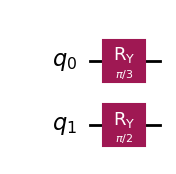

|00> amplitude=0.6124, probability=0.3750
|01> amplitude=0.6124, probability=0.3750
|10> amplitude=0.3536, probability=0.1250
|11> amplitude=0.3536, probability=0.1250


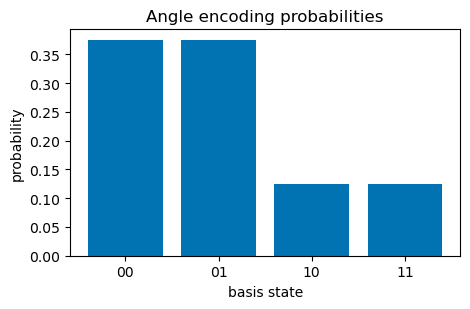

In [3]:
x = np.array([np.pi / 3, np.pi / 2], dtype=float)
qc_angle_two = QuantumCircuit(2)
qc_angle_two.ry(x[0], 0)
qc_angle_two.ry(x[1], 1)

try:
    display(qc_angle_two.draw(output="mpl", fold=-1))
except Exception as exc:
    print("mpl unavailable:", exc)
    print(qc_angle_two.draw(output="text"))

labels = ["00", "01", "10", "11"]
c = np.cos(x / 2)
s = np.sin(x / 2)
amps_two = np.array(
    [
        c[0] * c[1],
        c[0] * s[1],
        s[0] * c[1],
        s[0] * s[1],
    ]
)
probs_two = amps_two**2

for label, amp, prob in zip(labels, amps_two, probs_two):
    print(f"|{label}> amplitude={amp:.4f}, probability={prob:.4f}")

plt.figure(figsize=(4.8, 3.2))
plt.bar(labels, probs_two, color="#0173B2")
plt.xlabel("basis state")
plt.ylabel("probability")
plt.title("Angle encoding probabilities")
plt.tight_layout()
plt.savefig("angle_encoding_probabilities.png", dpi=110)
plt.show()

### Amplitude encoding: one vector

Amplitude encoding stores a normalized vector directly in the state amplitudes.
For two qubits, four real numbers can be stored as
$$
|x\rangle = x_0|00\rangle+x_1|01\rangle+x_2|10\rangle+x_3|11\rangle ,
\qquad
\sum_i x_i^2=1.
$$

The vector $(1,2,0,1)$ is not normalized. Dividing by its norm $\sqrt{6}$
gives amplitudes $(1/\sqrt{6},2/\sqrt{6},0,1/\sqrt{6})$.


raw vector: [1. 2. 0. 1.]
normalized amplitudes: [0.4082 0.8165 0.     0.4082]
probabilities: [0.1667 0.6667 0.     0.1667]
norm: 1.0
|00> amplitude=0.4082, probability=0.1667
|01> amplitude=0.8165, probability=0.6667
|10> amplitude=0.0000, probability=0.0000
|11> amplitude=0.4082, probability=0.1667


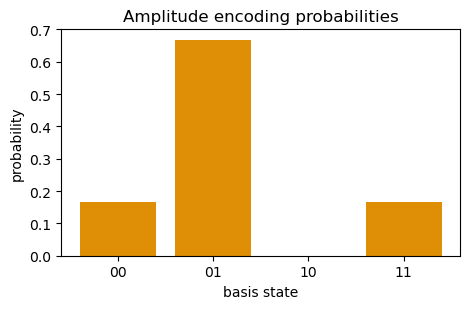

In [4]:
raw = np.array([1.0, 2.0, 0.0, 1.0])
amplitudes = raw / np.linalg.norm(raw)
probs_amp = amplitudes**2

print("raw vector:", raw)
print("normalized amplitudes:", np.round(amplitudes, 4))
print("probabilities:", np.round(probs_amp, 4))
print("norm:", np.linalg.norm(amplitudes))

sv_amp = Statevector(amplitudes)
for label, amp, prob in zip(labels, sv_amp.data, probs_amp):
    print(f"|{label}> amplitude={amp.real:.4f}, probability={prob:.4f}")

plt.figure(figsize=(4.8, 3.2))
plt.bar(labels, probs_amp, color="#DE8F05")
plt.xlabel("basis state")
plt.ylabel("probability")
plt.title("Amplitude encoding probabilities")
plt.tight_layout()
plt.savefig("amplitude_encoding_probabilities.png", dpi=110)
plt.show()

### Same idea in PennyLane

`qml.AngleEmbedding` automates the rotation pattern used above. It does not
make the modelling choice disappear: the feature scaling is still part of the
model design.


In [5]:
dev_tmp = qml.device("default.qubit", wires=2)

@qml.qnode(dev_tmp)
def angle_embed_pl(v):
    qml.AngleEmbedding(v, wires=[0, 1], rotation="Y")
    return qml.probs(wires=[0, 1])

print("PennyLane AngleEmbedding probabilities:")
print(np.round(angle_embed_pl(x), 4))

PennyLane AngleEmbedding probabilities:
[0.375 0.375 0.125 0.125]


---
## Part A · Quantum Neural Network (QNN) Classifier

A **Quantum Neural Network (QNN)** here means a parameterized quantum circuit (PQC) wrapped as a differentiable PyTorch layer (`qml.qnn.TorchLayer`), composed with classical layers in a single `nn.Sequential` model. Forward pass: classical pre-processing → angle encoding → variational layers → measurement → classical post-processing. Backward pass: PyTorch's `.backward()` propagates gradients through both classical and quantum components.

### Dataset: Two Moons

A standard non-linearly separable 2-D benchmark. A linear classifier scores around 85%; a reasonable hybrid model should exceed 90%.

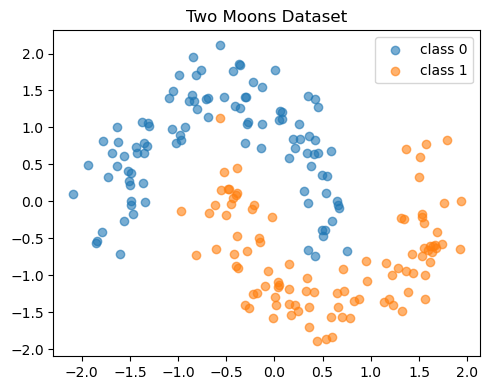

In [6]:
# ── Dataset ───────────────────────────────────────────────────────────────
X_raw, y = make_moons(n_samples=200, noise=0.15, random_state=42)
scaler = StandardScaler()
X_sc = scaler.fit_transform(X_raw)

X_tr, X_te, y_tr, y_te = train_test_split(X_sc, y, test_size=0.3, random_state=42)

X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
X_te_t = torch.tensor(X_te, dtype=torch.float32)
y_tr_t = torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1)
y_te_t = torch.tensor(y_te, dtype=torch.float32).unsqueeze(1)

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(*X_sc[y==0].T, label='class 0', alpha=0.6)
ax.scatter(*X_sc[y==1].T, label='class 1', alpha=0.6)
ax.set_title('Two Moons Dataset')
ax.legend(); plt.tight_layout()
plt.savefig('moons.png', dpi=80); plt.show()

### A.2 — QNode definition

We use `diff_method='backprop'` so gradients flow through the quantum circuit into PyTorch's `.backward()`.

In [7]:
N_QUBITS = 4
N_LAYERS = 2

dev_qnn = qml.device('default.qubit', wires=N_QUBITS)

@qml.qnode(dev_qnn, interface='torch', diff_method='backprop')
def qnn_circuit(inputs, weights):
    # Angle embedding: scale inputs to [0, π]
    qml.AngleEmbedding(inputs * np.pi, wires=range(N_QUBITS), rotation='Y')
    # Variational layers
    for l in range(N_LAYERS):
        for i in range(N_QUBITS):
            qml.Rot(weights[l, i, 0], weights[l, i, 1], weights[l, i, 2], wires=i)
        for i in range(N_QUBITS):
            qml.CNOT(wires=[i, (i + 1) % N_QUBITS])
    return qml.expval(qml.PauliZ(0))

weight_shapes = {'weights': (N_LAYERS, N_QUBITS, 3)}
qlayer = qml.qnn.TorchLayer(qnn_circuit, weight_shapes)

model = nn.Sequential(
    nn.Linear(2, N_QUBITS),
    nn.Tanh(),
    qlayer,
    nn.Sigmoid()
)

total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f'\nTotal trainable parameters: {total_params}')

Sequential(
  (0): Linear(in_features=2, out_features=4, bias=True)
  (1): Tanh()
  (2): <Quantum Torch Layer: func=qnn_circuit>
  (3): Sigmoid()
)

Total trainable parameters: 36


### A.3 — Training loop

In [8]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.05)
criterion = nn.BCELoss()

train_losses, train_accs = [], []
N_EPOCHS = 60

for epoch in range(N_EPOCHS):
    model.train()
    optimizer.zero_grad()
    preds = model(X_tr_t).reshape(-1, 1)
    loss = criterion(preds, y_tr_t)
    loss.backward()   # gradients flow through classical AND quantum layers
    optimizer.step()

    acc = ((preds > 0.5).float() == y_tr_t).float().mean().item()
    train_losses.append(loss.item())
    train_accs.append(acc)

    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d} | loss={loss.item():.4f} | train_acc={acc:.3f}')

model.eval()
with torch.no_grad():
    te_preds = model(X_te_t).reshape(-1, 1)
    te_acc = ((te_preds > 0.5).float() == y_te_t).float().mean().item()
print(f'\nTest accuracy: {te_acc:.3f}')

Epoch   0 | loss=0.6573 | train_acc=0.721
Epoch  10 | loss=0.5361 | train_acc=0.886
Epoch  20 | loss=0.4795 | train_acc=0.893
Epoch  30 | loss=0.4573 | train_acc=0.914
Epoch  40 | loss=0.4455 | train_acc=0.929
Epoch  50 | loss=0.4394 | train_acc=0.936

Test accuracy: 0.833


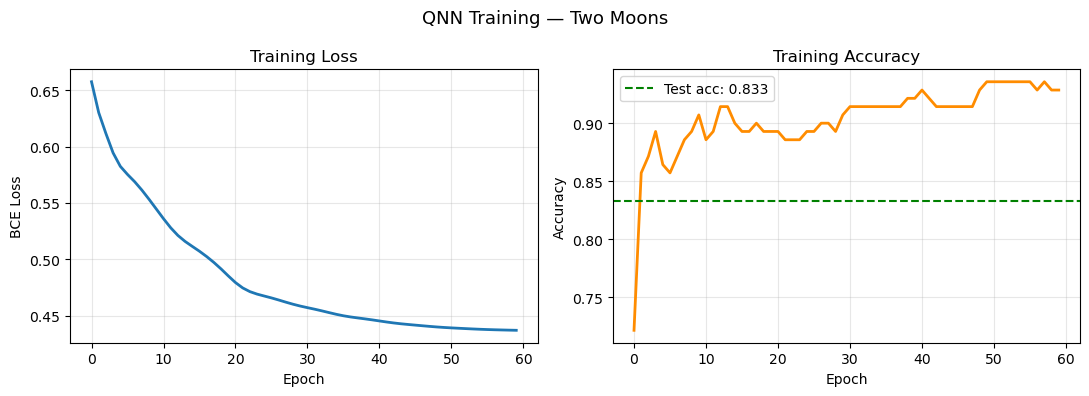

In [9]:
# ── Training curves ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(train_losses, lw=2); axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss'); axes[0].grid(alpha=0.3)

axes[1].plot(train_accs, lw=2, color='darkorange')
axes[1].axhline(te_acc, ls='--', color='green', label=f'Test acc: {te_acc:.3f}')
axes[1].set_title('Training Accuracy'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('QNN Training — Two Moons', fontsize=13)
plt.tight_layout(); plt.savefig('qnn_training.png', dpi=80); plt.show()

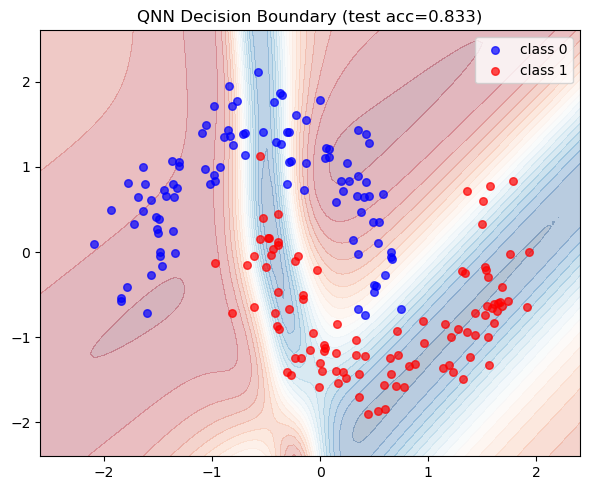

In [10]:
# ── Decision boundary ─────────────────────────────────────────────────────
h = 0.05
x_min, x_max = X_sc[:, 0].min()-0.5, X_sc[:, 0].max()+0.5
y_min, y_max = X_sc[:, 1].min()-0.5, X_sc[:, 1].max()+0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

model.eval()
with torch.no_grad():
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    Z = model(grid).numpy().reshape(xx.shape)

fig, ax = plt.subplots(figsize=(6, 5))
ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu', levels=20)
ax.scatter(*X_sc[y==0].T, c='blue', label='class 0', alpha=0.7, s=30)
ax.scatter(*X_sc[y==1].T, c='red',  label='class 1', alpha=0.7, s=30)
ax.set_title(f'QNN Decision Boundary (test acc={te_acc:.3f})')
ax.legend(); plt.tight_layout()
plt.savefig('qnn_boundary.png', dpi=80); plt.show()

---

## Part B · Financial example: portfolio selection

Qiskit Finance presents portfolio optimisation as a mean-variance objective:
reward expected return, penalise risk, and enforce a budget. Here we implement
the same idea directly with a tiny PennyLane circuit.

The circuit does not know finance. It only learns a probability distribution
over bitstrings. The classical part defines what each bitstring means and how
expensive it is.


In [11]:
def train_variational_sampler(
    costs: np.ndarray,
    num_qubits: int,
    steps: int = 180,
    lr: float = 0.08,
    seed: int = 0,
):
    """Train a small circuit to put probability on low-cost bitstrings."""
    torch.manual_seed(seed)
    dev = qml.device("default.qubit", wires=num_qubits)
    cost_tensor = torch.tensor(costs, dtype=torch.float32)

    @qml.qnode(dev, interface="torch", diff_method="backprop")
    def sampler(params):
        for wire in range(num_qubits):
            qml.Hadamard(wires=wire)
        for wire in range(num_qubits):
            qml.RY(params[0, wire], wires=wire)
        for wire in range(num_qubits - 1):
            qml.CNOT(wires=[wire, wire + 1])
        for wire in range(num_qubits):
            qml.RY(params[1, wire], wires=wire)
        return qml.probs(wires=list(range(num_qubits)))

    params = torch.nn.Parameter(0.1 * torch.randn(2, num_qubits))
    opt = torch.optim.Adam([params], lr=lr)
    history = []

    for step in range(steps):
        opt.zero_grad()
        probs = sampler(params)
        loss = torch.sum(probs * cost_tensor)
        loss.backward()
        opt.step()
        if step % 5 == 0:
            history.append(float(loss.detach()))

    return sampler(params).detach().numpy(), np.array(history)


def bitstrings(num_bits: int) -> list[str]:
    return [format(i, f"0{num_bits}b") for i in range(2**num_bits)]


def plot_sampler_result(labels, costs, probs, title, filename):
    fig, axes = plt.subplots(1, 2, figsize=(8.0, 3.2))
    axes[0].bar(labels, costs, color="#0173B2")
    axes[0].set_title("classical cost")
    axes[0].set_ylabel("lower is better")
    axes[0].tick_params(axis="x", rotation=45)

    axes[1].bar(labels, probs, color="#DE8F05")
    axes[1].set_title("trained circuit probabilities")
    axes[1].set_ylabel("probability")
    axes[1].tick_params(axis="x", rotation=45)

    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(filename, dpi=110)
    plt.show()

### Portfolio objective

There are three assets. A bitstring says which assets are selected:
$z=101$ means "take asset 0 and asset 2".

The toy cost is
$$
E(z)
=
0.6\,\text{risk}(z)
-
\text{return}(z)
+
2.0\left(\sum_i z_i - 2\right)^2.
$$

The last term makes portfolios with the wrong number of selected assets
expensive. The trainable circuit is asked to place probability on low-cost
bitstrings.


best classical bitstring: 101
most likely sampled bitstring: 101
selected assets: [0, 2]


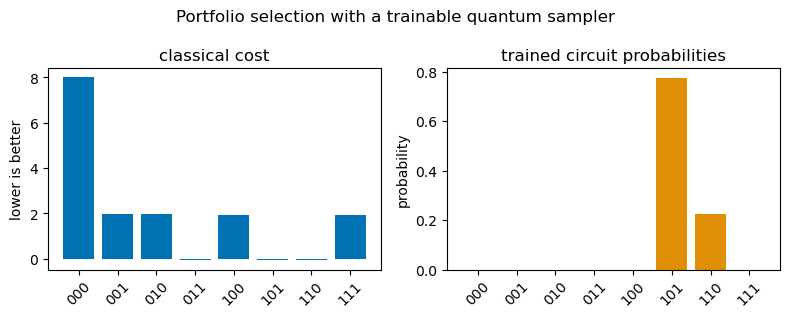

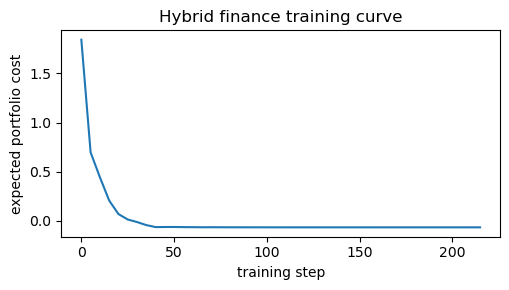

In [12]:
returns = np.array([0.12, 0.09, 0.07])
covariance = np.array(
    [
        [0.10, 0.03, 0.02],
        [0.03, 0.08, 0.01],
        [0.02, 0.01, 0.06],
    ]
)
risk_weight = 0.6
budget = 2
penalty = 2.0

finance_labels = bitstrings(3)
finance_costs = []
for label in finance_labels:
    z = np.array([int(bit) for bit in label])
    risk = z @ covariance @ z
    reward = returns @ z
    cost = risk_weight * risk - reward + penalty * (z.sum() - budget) ** 2
    finance_costs.append(cost)
finance_costs = np.array(finance_costs)

finance_probs, finance_history = train_variational_sampler(
    finance_costs,
    num_qubits=3,
    steps=220,
    lr=0.07,
    seed=1,
)

best_index = int(np.argmin(finance_costs))
most_likely = int(np.argmax(finance_probs))
print("best classical bitstring:", finance_labels[best_index])
print("most likely sampled bitstring:", finance_labels[most_likely])
print("selected assets:", [i for i, bit in enumerate(finance_labels[most_likely]) if bit == "1"])

plot_sampler_result(
    finance_labels,
    finance_costs,
    finance_probs,
    "Portfolio selection with a trainable quantum sampler",
    "hybrid_finance_sampler.png",
)

plt.figure(figsize=(5.2, 3.0))
plt.plot(np.arange(len(finance_history)) * 5, finance_history)
plt.xlabel("training step")
plt.ylabel("expected portfolio cost")
plt.title("Hybrid finance training curve")
plt.tight_layout()
plt.savefig("hybrid_finance_training.png", dpi=110)
plt.show()

---

## Part C · Logistics example: route choice

For a beginner lab, a full TSP encoding is unnecessarily heavy. We instead
compare four candidate routes through the same four cities. Two measured qubits
select one of the four routes.

This is still the same hybrid pattern: the classical code computes route
lengths, and the trainable circuit learns to sample the shorter route more
often.


00: A->B->C->D->A   length=3.575, probability=1.000
01: A->B->D->C->A   length=4.248, probability=0.000
10: A->C->B->D->A   length=4.328, probability=0.000
11: A->C->D->B->A   length=4.248, probability=0.000


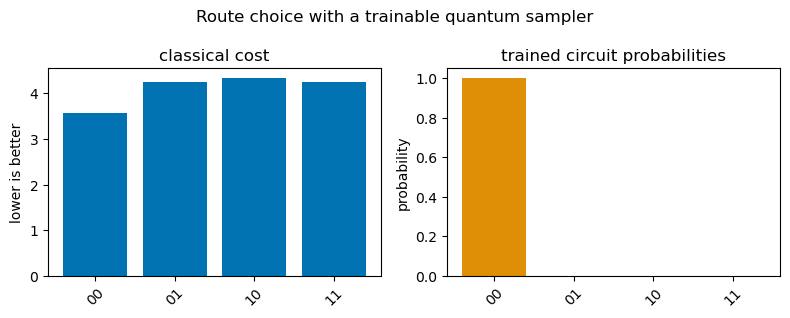

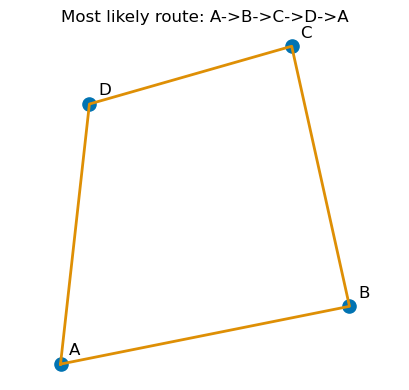

In [13]:
city_names = ["A", "B", "C", "D"]
coords = np.array(
    [
        [0.0, 0.0],
        [1.0, 0.2],
        [0.8, 1.1],
        [0.1, 0.9],
    ]
)
candidate_routes = [
    (0, 1, 2, 3),
    (0, 1, 3, 2),
    (0, 2, 1, 3),
    (0, 2, 3, 1),
]

distance = np.linalg.norm(coords[:, None, :] - coords[None, :, :], axis=2)


def route_length(route):
    return sum(
        distance[route[i], route[(i + 1) % len(route)]]
        for i in range(len(route))
    )


route_labels = bitstrings(2)
route_names = [
    "->".join(city_names[i] for i in (*route, route[0]))
    for route in candidate_routes
]
route_costs = np.array([route_length(route) for route in candidate_routes])

route_probs, route_history = train_variational_sampler(
    route_costs,
    num_qubits=2,
    steps=180,
    lr=0.08,
    seed=2,
)

for label, route, cost, prob in zip(route_labels, route_names, route_costs, route_probs):
    print(f"{label}: {route:15s} length={cost:.3f}, probability={prob:.3f}")

best_route_index = int(np.argmax(route_probs))
best_route = candidate_routes[best_route_index]
closed_route = np.array([*best_route, best_route[0]])

plot_sampler_result(
    route_labels,
    route_costs,
    route_probs,
    "Route choice with a trainable quantum sampler",
    "hybrid_logistics_sampler.png",
)

plt.figure(figsize=(4.2, 4.0))
plt.scatter(coords[:, 0], coords[:, 1], s=90, color="#0173B2")
for name, (x_pos, y_pos) in zip(city_names, coords):
    plt.text(x_pos + 0.03, y_pos + 0.03, name, fontsize=12)
plt.plot(
    coords[closed_route, 0],
    coords[closed_route, 1],
    color="#DE8F05",
    linewidth=2,
)
plt.title(f"Most likely route: {route_names[best_route_index]}")
plt.axis("equal")
plt.axis("off")
plt.tight_layout()
plt.savefig("hybrid_logistics_route.png", dpi=110)
plt.show()

### What these examples show

The quantum circuit is not a magic optimiser. In both examples the difficult
modelling choices are classical: define the candidates, compute their costs,
and verify the sampled answer. The hybrid step is the training loop that tries
to make low-cost candidates more likely under measurement.


---

### Hybrid limitations

**Barren plateaus.** Random deep unstructured ansätze often yield exponentially vanishing gradient variance in qubit count (McClean et al., 2018).

**Encoding.** Performance hinges on how classical features become rotations,
amplitudes, or bitstring costs.

**Possible upside.** Useful circuit structure could capture correlations,
shape sampling probabilities, improve convergence, or reduce overfitting on
some tasks.

**Evidence standard.** Treat shot noise, runtime, and classical baselines
honestly before claiming value.
